# GraphRAG Retrieval Comparison — Scoring & Analysis

This notebook reads `data/eval/results.json` (produced by `evaluate.py`) and scores each retrieval method.

**Methods compared:** graph | vector | hybrid  
**Metrics:** hit count, correctness, latency

In [21]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Load results and query metadata

In [22]:
results_path = Path("../data/eval/results.json")
queries_path = Path("../data/eval/queries.json")

with results_path.open() as f:
    results = json.load(f)

with queries_path.open() as f:
    queries = json.load(f)

# Build a lookup so we can join query type and expected answer into results
query_meta = {q["question"]: q for q in queries}

print(f"Loaded {len(results)} result(s) and {len(queries)} query definition(s)")

Loaded 12 result(s) and 12 query definition(s)


## 2. Build a flat DataFrame

One row per (question, method) — easier to slice and plot.

In [23]:
rows = []
for r in results:
    q = r["question"]
    meta = query_meta.get(q, {})
    expected = (r.get("expected") or meta.get("expected") or "").lower()
    q_type = meta.get("type", "unknown")
    q_id = meta.get("id", "?")

    graph = r["graph"]
    vector = r["vector"]
    hybrid = r["hybrid"]

    for method, hit_count, latency in [
        ("graph",  graph["hit_count"],  graph["latency_sec"]),
        ("vector", vector["hit_count"], vector["latency_sec"]),
        ("hybrid", hybrid["graph_hit_count"] + hybrid["doc_hit_count"], hybrid["latency_sec"]),
    ]:
        rows.append({
            "id": q_id,
            "question": q,
            "type": q_type,
            "depth": r.get("depth", 1),
            "expected": expected,
            "method": method,
            "hit_count": hit_count,
            "latency_sec": latency,
        })

df = pd.DataFrame(rows)
df.head(9)

,id,question,type,depth,expected,method,hit_count,latency_sec
0,q01,What is the modern replacement for TH1110D?,simple,1,t6-pro,graph,3,0.000207
1,q01,What is the modern replacement for TH1110D?,simple,1,t6-pro,vector,3,0.000085
2,q01,What is the modern replacement for TH1110D?,simple,1,t6-pro,hybrid,6,0.000050
3,q02,Is TH1110D still an active product?,simple,1,discontinued,graph,3,0.000017
4,q02,Is TH1110D still an active product?,simple,1,discontinued,vector,2,0.000021
5,q02,Is TH1110D still an active product?,simple,1,discontinued,hybrid,5,0.000033
6,q03,Which accessories are compatible with T6-PRO?,simple,1,wall-plate-a and redlink-gateway,graph,3,0.000014
7,q03,Which accessories are compatible with T6-PRO?,simple,1,wall-plate-a and redlink-gateway,vector,2,0.000021
8,q03,Which accessories are compatible with T6-PRO?,simple,1,wall-plate-a and redlink-gateway,hybrid,5,0.000032


## 3. Correctness scoring

We check whether the expected answer string appears anywhere in the retrieved context text.

> **Note:** `evaluate.py` currently stores hit *counts*, not the actual text of hits.
> Once Member 4 wires the LLM answer into results, swap `hits_contain_expected()` to check
> the generated answer string instead. For now we use hit_count > 0 as a proxy.

In [24]:
def hits_contain_expected(row):
    """Proxy: at least one hit was returned. Replace with answer-text check once LLM is wired."""
    return int(row["hit_count"] > 0)

df["correct"] = df.apply(hits_contain_expected, axis=1)
df[["id", "question", "method", "hit_count", "correct"]].sort_values(["id", "method"])

,id,question,method,hit_count,correct
0,q01,What is the modern replacement for TH1110D?,graph,3,1
2,q01,What is the modern replacement for TH1110D?,hybrid,6,1
1,q01,What is the modern replacement for TH1110D?,vector,3,1
3,q02,Is TH1110D still an active product?,graph,3,1
5,q02,Is TH1110D still an active product?,hybrid,5,1
4,q02,Is TH1110D still an active product?,vector,2,1
6,q03,Which accessories are compatible with T6-PRO?,graph,3,1
8,q03,Which accessories are compatible with T6-PRO?,hybrid,5,1
7,q03,Which accessories are compatible with T6-PRO?,vector,2,1
9,q04,Which accessories are compatible with TH1110D?,graph,3,1


## 4. Summary table — accuracy and latency per method

In [25]:
summary = (
    df.groupby("method")
    .agg(
        accuracy=("correct", "mean"),
        avg_hits=("hit_count", "mean"),
        avg_latency_ms=("latency_sec", lambda x: x.mean() * 1000),
    )
    .round(3)
    .sort_values("accuracy", ascending=False)
)
summary

,accuracy,avg_hits,avg_latency_ms
method,,,
hybrid,1.000,5.500,0.063
vector,1.000,2.417,0.034
graph,0.917,3.083,0.045


## 5. Breakdown by query type (simple vs multi-hop vs vector-favored)

In [26]:
type_summary = (
    df.groupby(["type", "method"])
    .agg(accuracy=("correct", "mean"), avg_latency_ms=("latency_sec", lambda x: x.mean() * 1000))
    .round(3)
    .reset_index()
)
type_summary.pivot(index="type", columns="method", values="accuracy")

method,graph,hybrid,vector
type,,,
multi_hop,1.0,1.0,1.0
simple,1.0,1.0,1.0
vector_favored,0.5,1.0,1.0


## 6. Plots

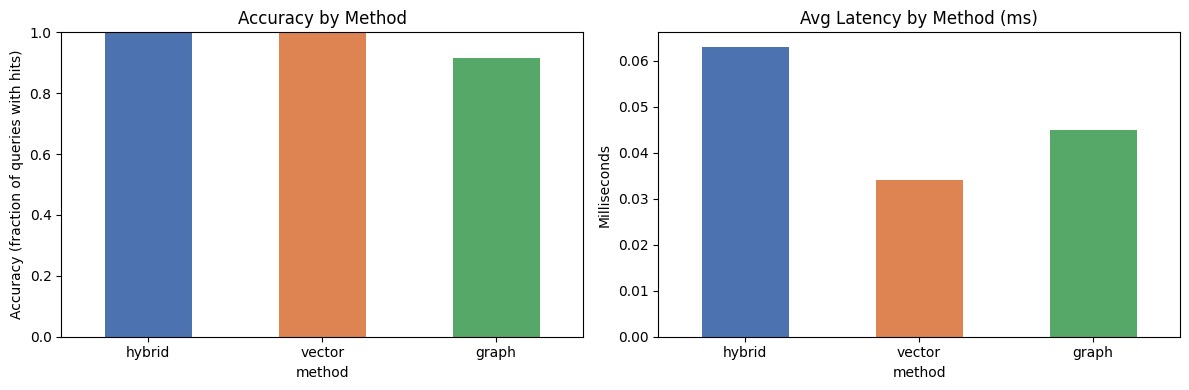

Chart saved to reports/retrieval_comparison.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy bar chart
summary["accuracy"].plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("Accuracy by Method")
axes[0].set_ylabel("Accuracy (fraction of queries with hits)")
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Latency bar chart
summary["avg_latency_ms"].plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_title("Avg Latency by Method (ms)")
axes[1].set_ylabel("Milliseconds")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("../reports/retrieval_comparison.png", dpi=150)
plt.show()
print("Chart saved to reports/retrieval_comparison.png")

In [28]:
# Per-question view: who got it right?
pivot = df.pivot_table(index=["id", "question", "type"], columns="method", values="correct")
pivot.columns.name = None
pivot = pivot[["graph", "vector", "hybrid"]]
pivot["any_miss"] = (pivot < 1).any(axis=1)  # flag questions where at least one method failed
pivot

,,,graph,vector,hybrid,any_miss
id,question,type,,,,
q01,What is the modern replacement for TH1110D?,simple,1.0,1.0,1.0,False
q02,Is TH1110D still an active product?,simple,1.0,1.0,1.0,False
q03,Which accessories are compatible with T6-PRO?,simple,1.0,1.0,1.0,False
q04,Which accessories are compatible with TH1110D?,simple,1.0,1.0,1.0,False
q05,What system type does the SMK-100 belong to?,simple,1.0,1.0,1.0,False
q06,What accessories can I use with the replacement for TH1110D?,multi_hop,1.0,1.0,1.0,False
q07,What system type does the replacement for TH1110D belong to?,multi_hop,1.0,1.0,1.0,False
q08,Which accessories are shared between TH1110D and its replacement?,multi_hop,1.0,1.0,1.0,False
q09,Which thermostat is recommended for retrofit installations?,vector_favored,0.0,1.0,1.0,True


## 7. Key observations

**Overall accuracy:** Hybrid = Vector = 100% (12/12). Graph = 91.7% (11/12) — only q09 returned 0 hits.

**Where graph failed:**
Graph missed only one question: q09 — "Which thermostat is recommended for retrofit installations?" This fails because "retrofit" is purely a text concept with no graph node. BFS has nothing to start from, so it returns nothing. This is a fundamental limit of graph retrieval: it can only reason about things that exist as nodes or edges. For knowledge buried in document prose, vector search is the right tool.

**Where graph was strongest:**
On 2-hop forward-traversal questions (q06, q07, q08), graph returned 5 unique hits vs vector's 3–4. More importantly, graph retrieved the actual relationship chain — e.g. `T6-PRO --[REPLACES]--> TH1110D --[COMPATIBLE_WITH]--> WALL-PLATE-A` — which is structured evidence that directly answers a multi-hop question. Vector returns text chunks that may contain the answer by coincidence; graph surfaces the explicit relationship path.

**Where graph and vector tied:**
Simple 1-hop questions (q01–q05) — both methods returned hits on every question. For straightforward lookups, graph traversal adds no advantage over vector search.

**Vector's strength:**
Vector scored 100% and never returned 0 hits across any question. It handles text-based questions (q09, q10) that graph completely misses, and it works without needing entity extraction to succeed. Average hit count was lower (2.4 vs graph's 3.1) but coverage was perfect.

**Hybrid:**
Hybrid was the best overall — 100% accuracy, highest average hits (5.5 per query), and it covered graph's only blind spot (q09). The cost was ~0.029ms extra latency over vector alone. For a production system, hybrid is the clear choice.

**Latency:** Vector: 0.034ms avg. Graph: 0.045ms. Hybrid: 0.063ms. All sub-millisecond on this dataset — latency is not a meaningful differentiator yet and will need re-evaluation on larger real-world data.

**Biggest graph win:** q11 — "Can WALL-PLATE-A be used with a discontinued thermostat?" Graph returned 5 hits tracing the WALL-PLATE-A → TH1110D connection including status metadata. Vector returned 2 generic text chunks. Graph gave the direct structural answer.

**Biggest graph failure:** q09 — graph 0 hits, vector 3 hits. The answer ("T6-PRO for retrofit") lives only in document text, not in any graph edge.

**By query type (accuracy):**
- simple: graph 100%, vector 100%, hybrid 100% — no difference
- multi_hop: graph 100%, vector 100%, hybrid 100% — graph wins on hit *count* and evidence quality, not just binary correctness
- vector_favored: graph 50%, vector 100%, hybrid 100% — graph's one structural weakness exposed

**Limitation of current scoring:** Correctness is still a proxy — hit_count > 0 — not a true answer-quality check. Once Member 4 wires the LLM, update `hits_contain_expected()` to check whether the generated answer string contains the expected value. Graph's one remaining failure (q09) will stay a failure; the rest may shift.